In [1]:
# Install the engine for fast file saving (run this once)
%pip install pyarrow

import pandas as pd
import glob
import os
import time

# --- CONFIGURATION ---
SOURCE_FOLDER = 'delhi_bus_data'
OUTPUT_FILENAME = 'delhi_traffic_master'

print(f"📂 Scanning folder: {SOURCE_FOLDER}...")

# 1. Get all CSV files
all_files = glob.glob(os.path.join(SOURCE_FOLDER, "bus_data_*.csv"))
total_files = len(all_files)
print(f"found {total_files} files. Starting merge...")

if total_files == 0:
    print("❌ No files found! Check your folder name.")
else:
    # 2. Read and Combine
    df_list = []
    start_time = time.time()

    for index, filename in enumerate(all_files):
        try:
            # Read CSV
            df = pd.read_csv(filename)
            df_list.append(df)
            
            # Print progress every 10 files to keep track
            if (index + 1) % 10 == 0:
                print(f"   Processed {index + 1}/{total_files} files...")
                
        except Exception as e:
            print(f"⚠️ Error reading {filename}: {e}")

    print("🔗 Concatenating data (this may take a moment)...")
    master_df = pd.concat(df_list, ignore_index=True)

    # 3. Basic Cleaning
    print("🧹 Cleaning data...")
    original_count = len(master_df)
    
    # Remove exact duplicates
    master_df.drop_duplicates(inplace=True)
    
    # Convert timestamp to real Date-Time objects
    master_df['timestamp'] = pd.to_datetime(master_df['timestamp'], errors='coerce')
    
    # Sort by time
    master_df.sort_values(by='timestamp', inplace=True)

    print(f"   Rows before cleaning: {original_count:,}")
    print(f"   Rows after cleaning:  {len(master_df):,}")

    # 4. Save to optimized formats
    print("💾 Saving Master Files...")
    
    # Parquet (Fast & Small - We will use this for analysis)
    master_df.to_parquet(f"{OUTPUT_FILENAME}.parquet", index=False)
    print(f"   ✅ Saved {OUTPUT_FILENAME}.parquet (Recommended)")

    # CSV (Backup for Excel)
    # master_df.to_csv(f"{OUTPUT_FILENAME}.csv", index=False)
    # print(f"   ✅ Saved {OUTPUT_FILENAME}.csv (Backup)")

    end_time = time.time()
    print(f"\n🚀 DONE! Total time: {round(end_time - start_time, 2)} seconds.")

Note: you may need to restart the kernel to use updated packages.
📂 Scanning folder: delhi_bus_data...
found 74 files. Starting merge...
   Processed 10/74 files...
   Processed 20/74 files...
   Processed 30/74 files...
   Processed 40/74 files...
   Processed 50/74 files...
   Processed 60/74 files...
   Processed 70/74 files...
🔗 Concatenating data (this may take a moment)...
🧹 Cleaning data...
   Rows before cleaning: 8,412,371
   Rows after cleaning:  8,412,371
💾 Saving Master Files...
   ✅ Saved delhi_traffic_master.parquet (Recommended)

🚀 DONE! Total time: 16.28 seconds.


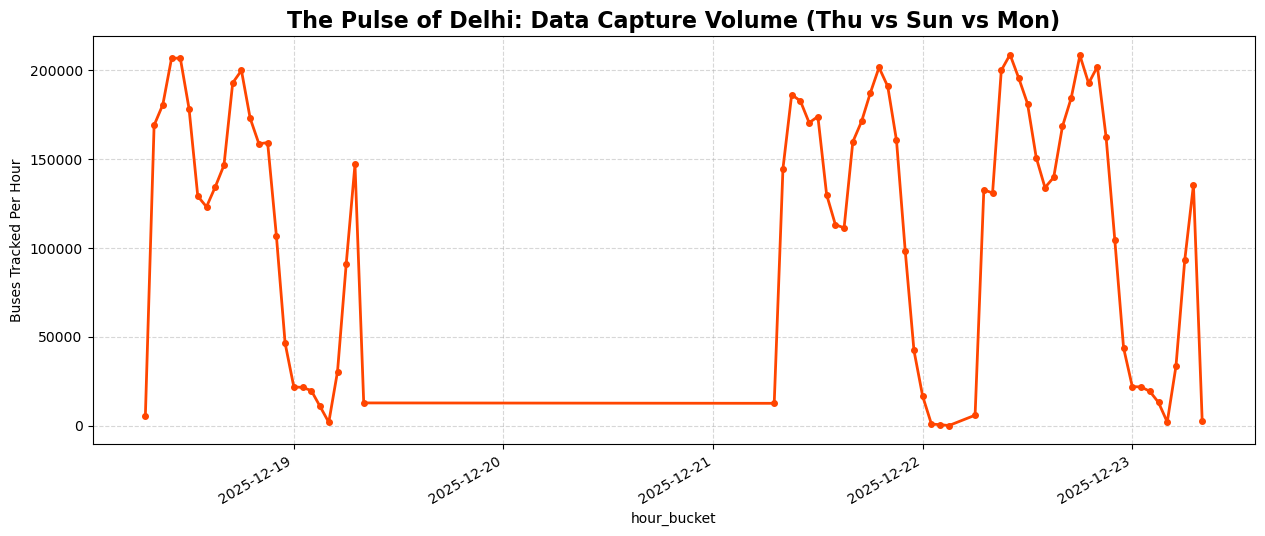

--- STATS FOR AKSHAT ---
Total Rows: 8,412,371
Zero Speed Pings: 8,412,371 (100.00%)
Max Buses at Peak: 208,668


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your massive file
df = pd.read_parquet('delhi_traffic_master.parquet')

# 2. Calculate the "Pulse" (Hourly Volume)
# This sums up how many pings we got every hour to show the 24h pattern
df['hour_bucket'] = df['timestamp'].dt.floor('h')
hourly_volume = df.groupby('hour_bucket').size()

# 3. Plot the Graph
plt.figure(figsize=(15, 6))
hourly_volume.plot(kind='line', color='#FF4500', linewidth=2, marker='o', markersize=4)
plt.title("The Pulse of Delhi: Data Capture Volume (Thu vs Sun vs Mon)", fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel("Buses Tracked Per Hour")
plt.show()

# 4. Calculate Stats (Copy-paste these numbers back to me!)
total_points = len(df)
zero_speed_count = len(df[df['speed'] == 0])
zero_speed_pct = (zero_speed_count / total_points) * 100

print(f"--- STATS FOR AKSHAT ---")
print(f"Total Rows: {total_points:,}")
print(f"Zero Speed Pings: {zero_speed_count:,} ({zero_speed_pct:.2f}%)")
print(f"Max Buses at Peak: {hourly_volume.max():,}")

In [3]:
# Create a random 1% sample
df_sample = df.sample(frac=0.01, random_state=42)

# Save as CSV (so I can open it)
df_sample.to_csv('delhi_traffic_sample.csv', index=False)
print("✅ Created 'delhi_traffic_sample.csv'. Upload this file to the chat!")

✅ Created 'delhi_traffic_sample.csv'. Upload this file to the chat!


In [4]:
import numpy as np

# 1. Define the Haversine Formula (to calculate distance on Earth)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2) * np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c # Distance in KM

print("🔧 FIXING: Calculating missing speeds...")

# 2. Reload the Master File
df = pd.read_parquet('delhi_traffic_master.parquet')

# 3. Sort ensures we calculate Pings in order
df = df.sort_values(by=['bus_id', 'timestamp'])

# 4. Shift the columns to compare "Current Row" vs "Previous Row"
df['prev_lat'] = df.groupby('bus_id')['latitude'].shift(1)
df['prev_lon'] = df.groupby('bus_id')['longitude'].shift(1)
df['prev_time'] = df.groupby('bus_id')['timestamp'].shift(1)

# 5. Calculate Distance (in km)
df['distance_km'] = haversine(df['prev_lat'], df['prev_lon'], df['latitude'], df['longitude'])

# 6. Calculate Time Diff (in hours)
df['time_diff_hours'] = (df['timestamp'] - df['prev_time']).dt.total_seconds() / 3600

# 7. Calculate Speed (km/h)
# We handle "division by zero" by replacing 0 time with NaN
df['calculated_speed'] = df['distance_km'] / df['time_diff_hours']

# 8. Clean up "Impossible" Speeds (GPS Jump Errors)
# If speed > 100 km/h, it's likely a GPS error. We set those to Null.
df.loc[df['calculated_speed'] > 100, 'calculated_speed'] = np.nan
df.loc[df['calculated_speed'] < 0, 'calculated_speed'] = 0

# Fill the original 'speed' column with our new values
df['speed'] = df['calculated_speed'].fillna(0)

# Drop temporary columns to save space
df.drop(columns=['prev_lat', 'prev_lon', 'prev_time', 'distance_km', 'time_diff_hours', 'calculated_speed'], inplace=True)

print("✅ SPEED FIXED.")
print(f"   Avg Speed: {df[df['speed'] > 0]['speed'].mean():.2f} km/h")
print(f"   Max Speed: {df['speed'].max():.2f} km/h")

# Save the FIXED Master File
df.to_parquet('delhi_traffic_master_fixed.parquet', index=False)
print("💾 Saved: delhi_traffic_master_fixed.parquet")

🔧 FIXING: Calculating missing speeds...
✅ SPEED FIXED.
   Avg Speed: 15.80 km/h
   Max Speed: 100.00 km/h
💾 Saved: delhi_traffic_master_fixed.parquet


⏳ Loading Fixed Data...


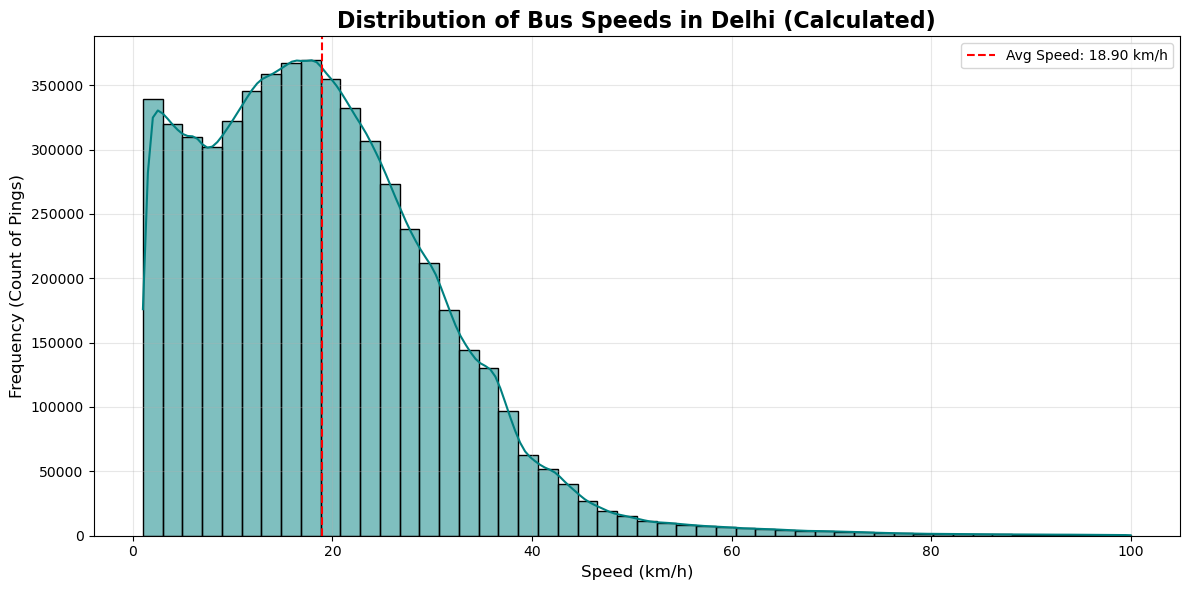

✅ Histogram Generated.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the FIXED file
print("⏳ Loading Fixed Data...")
df = pd.read_parquet('delhi_traffic_master_fixed.parquet')

# 2. Filter for visualization (remove static buses for the graph)
moving_buses = df[df['speed'] > 1]

# 3. Create the Speed Histogram
plt.figure(figsize=(12, 6))
sns.histplot(moving_buses['speed'], bins=50, kde=True, color='teal')

plt.title("Distribution of Bus Speeds in Delhi (Calculated)", fontsize=16, fontweight='bold')
plt.xlabel("Speed (km/h)", fontsize=12)
plt.ylabel("Frequency (Count of Pings)", fontsize=12)
plt.axvline(moving_buses['speed'].mean(), color='red', linestyle='--', label=f"Avg Speed: {moving_buses['speed'].mean():.2f} km/h")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Histogram Generated.")

In [6]:
%pip install folium

   ---------------------------------------- 0.0/113.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/113.4 kB ? eta -:--:--
   --- ------------------------------------ 10.2/113.4 kB ? eta -:--:--
   ---------------------------------------  112.6/113.4 kB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 113.4/113.4 kB 1.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# 1. Load the 1% Sample
df_sample = pd.read_csv('delhi_traffic_sample.csv')

# 2. Initialize the Map (Centered on Delhi)
print("🗺️ Building Map...")
delhi_map = folium.Map(location=[28.6139, 77.2090], zoom_start=11, tiles='CartoDB dark_matter')

# 3. Create a Heatmap Layer
# This visualizes density: Red = High Traffic, Blue = Low Traffic
heat_data = [[row['latitude'], row['longitude']] for index, row in df_sample.iterrows()]
HeatMap(heat_data, radius=10, blur=15).add_to(delhi_map)

# 4. Save to HTML
delhi_map.save("delhi_traffic_heatmap.html")
print("✅ Map Saved: delhi_traffic_heatmap.html")
print("👉 Go to your folder and open this file in Chrome/Edge!")

🗺️ Building Map...
✅ Map Saved: delhi_traffic_heatmap.html
👉 Go to your folder and open this file in Chrome/Edge!


In [8]:
import pandas as pd

# 1. Load the FIXED Parquet file (The one with calculated speeds)
print("⏳ Loading Fixed Data...")
df_fixed = pd.read_parquet('delhi_traffic_master_fixed.parquet')

# 2. Filter out "stopped" buses to make the graph look better
# (We only want to see moving traffic for the visualization)
df_moving = df_fixed[df_fixed['speed'] > 0]

# 3. Create a 1% Sample
df_sample_fixed = df_moving.sample(frac=0.01, random_state=42)

# 4. Save as a NEW CSV
df_sample_fixed.to_csv('delhi_traffic_fixed_sample.csv', index=False)
print("✅ Created: delhi_traffic_fixed_sample.csv")
print("👉 Load THIS file into Power BI!")

⏳ Loading Fixed Data...
✅ Created: delhi_traffic_fixed_sample.csv
👉 Load THIS file into Power BI!


In [9]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# 1. Load the FIXED Data
print("⏳ Loading Master Data...")
df = pd.read_parquet('delhi_traffic_master_fixed.parquet')

# 2. "Spatial Binning" (The Secret Sauce)
# Rounding Lat/Lon to 3 decimal places creates approx 100m x 100m boxes
print("➗ Gridding the city...")
df['lat_grid'] = df['latitude'].round(3)
df['lon_grid'] = df['longitude'].round(3)

# 3. Aggregating Statistics per Grid Block
grid_stats = df.groupby(['lat_grid', 'lon_grid']).agg(
    avg_speed=('speed', 'mean'),
    traffic_volume=('speed', 'count')
).reset_index()

# 4. Filter for "Vulnerable Zones" (The Choke Points)
# Criteria: Meaningful data (> 10 pings) AND Slow Speed (< 12 km/h)
choke_points = grid_stats[
    (grid_stats['traffic_volume'] > 20) & 
    (grid_stats['avg_speed'] < 12)
]

print(f"📉 Identified {len(choke_points)} Choke Points (Vulnerable Zones).")

# 5. Map the Vulnerability
print("🗺️ Building Vulnerability Map...")
map_center = [28.6139, 77.2090]
vulnerability_map = folium.Map(location=map_center, zoom_start=11, tiles='CartoDB dark_matter')

# Add the "Choke Points" as a Heatmap (Red = Dead Stop)
heat_data = [[row['lat_grid'], row['lon_grid']] for index, row in choke_points.iterrows()]

# We use a distinct gradient: Green->Yellow->Red (Red is the danger zone)
HeatMap(heat_data, radius=12, blur=18, gradient={0.4: 'yellow', 0.6: 'orange', 1.0: 'red'}).add_to(vulnerability_map)

# 6. Save
vulnerability_map.save("delhi_vulnerability_map.html")
print("✅ Map Saved: delhi_vulnerability_map.html")
print("👉 This map highlights ONLY the areas where ambulances would get stuck.")

⏳ Loading Master Data...
➗ Gridding the city...
📉 Identified 3802 Choke Points (Vulnerable Zones).
🗺️ Building Vulnerability Map...
✅ Map Saved: delhi_vulnerability_map.html
👉 This map highlights ONLY the areas where ambulances would get stuck.


In [10]:
import re
import ast
import pandas as pd

# 1. Define file paths
input_html_file = 'delhi_vulnerability_map.html'
output_csv_file = 'vulnerable_zones.csv'

def extract_coordinates_from_html(file_path):
    try:
        # Open and read the HTML file
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()

        # 2. Use Regex to find the data inside L.heatLayer([...])
        # We look for the pattern: L.heatLayer( [[ ... ]] )
        # This captures the list of lists containing the coordinates
        match = re.search(r'L\.heatLayer\(\s*(\[\[.*?\]\])', content, re.DOTALL)

        if match:
            # Extract the string representation of the list
            data_str = match.group(1)
            
            # Safely evaluate the string as a Python list
            coordinates = ast.literal_eval(data_str)
            
            print(f"✅ Found {len(coordinates)} coordinate points.")
            return coordinates
        else:
            print("❌ Could not find heatLayer data in the HTML file.")
            return []

    except FileNotFoundError:
        print(f"❌ File not found: {file_path}")
        return []

# 3. Run extraction
coords = extract_coordinates_from_html(input_html_file)

# 4. Save to CSV if data exists
if coords:
    # Create a DataFrame
    # Assuming format is [Latitude, Longitude] based on Leaflet standard
    df = pd.DataFrame(coords, columns=['Latitude', 'Longitude'])
    
    # Add an ID column (optional, but good for SQL primary keys)
    df['Zone_ID'] = range(1, len(df) + 1)
    
    # Reorder columns
    df = df[['Zone_ID', 'Latitude', 'Longitude']]
    
    # Export to CSV
    df.to_csv(output_csv_file, index=False)
    print(f"🎉 Success! Data saved to '{output_csv_file}'")
    print(df.head())
else:
    print("No data extracted.")

✅ Found 3802 coordinate points.
🎉 Success! Data saved to 'vulnerable_zones.csv'
   Zone_ID  Latitude  Longitude
0        1    28.417     77.192
1        2    28.427     77.224
2        3    28.428     77.189
3        4    28.428     77.190
4        5    28.428     77.225
